In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Define the MultipleLR class again for the script context
class MultipleLR:
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X_train, Y_train):
        X_train = np.insert(X_train, 0, 1, axis=1)
        betas = np.linalg.inv(np.dot(X_train.T, X_train)).dot(X_train.T).dot(Y_train)
        self.intercept_ = betas[0]
        self.coef_ = betas[1:]

    def predict(self, X_test):
        if self.coef_ is not None:
            return np.dot(X_test, self.coef_) + self.intercept_

    def r2_score(self, Y_true, Y_pred):
        ss_total = np.sum((Y_true - Y_true.mean()) ** 2)
        ss_res = np.sum((Y_true - Y_pred) ** 2)
        return 1 - (ss_res / ss_total)

# 1. Generate Synthetic Dataset
np.random.seed(42)
n_samples = 50
X1 = np.random.uniform(1, 10, n_samples)  # Study Hours
X2 = np.random.uniform(50, 100, n_samples) # Attendance %
X = np.column_stack((X1, X2))

# Target: Exam Score = 3*X1 + 0.4*X2 + noise
noise = np.random.normal(0, 2, n_samples)
Y = 3 * X1 + 0.4 * X2 + 5 + noise

# 2. Train Model
model = MultipleLR()
model.fit(X, Y)
Y_pred = model.predict(X)
print(f"R2 Score: {model.r2_score(Y, Y_pred):.4f}")

R2 Score: 0.9687


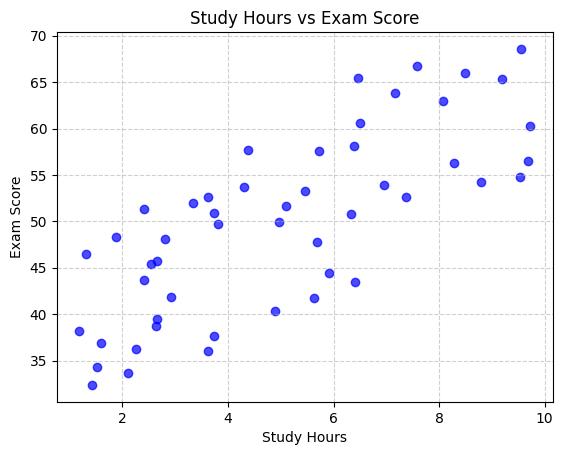

In [15]:
# Plot 1: Study Hours vs Exam Score
plt.scatter(X1, Y, color='blue', alpha=0.7, label='Actual')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.title('Study Hours vs Exam Score')
plt.grid(True, linestyle='--', alpha=0.6)



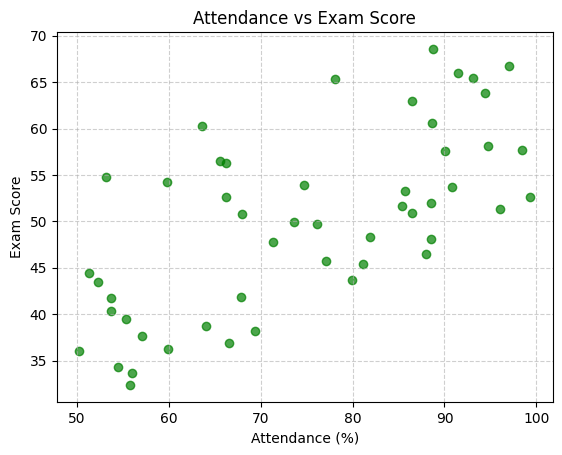

In [13]:
# Plot 2: Attendance vs Exam Score
plt.scatter(X2, Y, color='green', alpha=0.7, label='Actual')
plt.xlabel('Attendance (%)')
plt.ylabel('Exam Score')
plt.title('Attendance vs Exam Score')
plt.grid(True, linestyle='--', alpha=0.6)


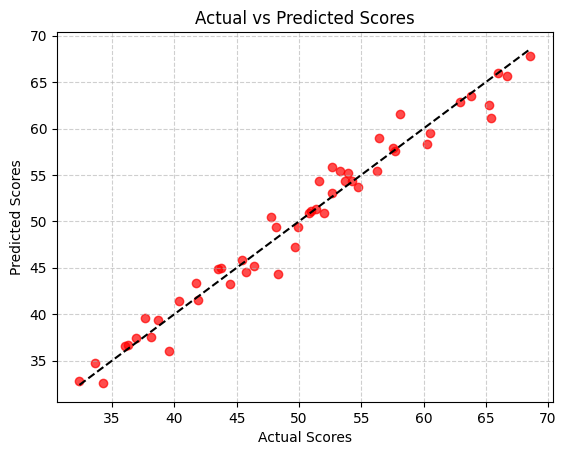

In [14]:
# Plot 3: Actual vs Predicted (Standard for Regression)
plt.scatter(Y, Y_pred, color='red', alpha=0.7)
# Plot the ideal 45-degree line
min_val = min(min(Y), min(Y_pred))
max_val = max(max(Y), max(Y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--')
plt.xlabel('Actual Scores')
plt.ylabel('Predicted Scores')
plt.title('Actual vs Predicted Scores')
plt.grid(True, linestyle='--', alpha=0.6)
